## What are the most demanded skills for the top 3 most popular data roles?

### Methodology
1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings

### Import Libraries and Data

In [2]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter Data for EU region

In [3]:
europe_countries = [
    "Albania", "Andorra", "Austria", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus",
    "Czech Republic", "Denmark", "Estonia", "Finland", "France",
    "Germany", "Greece", "Hungary", "Iceland", "Ireland",
    "Italy", "Kosovo", "Latvia", "Liechtenstein", "Lithuania",
    "Luxembourg", "Malta", "Moldova", "Monaco", "Montenegro",
    "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom", "Vatican City"
]

df_eu = df[df['job_country'].isin(europe_countries)]


### Explode skill column

Converts the `job_skills` column from string representations of lists into actual list objects and then expands these lists so each skill appears in its own row. It then displays the `job_title` and `job_skills` columns, allowing us to analyze the distribution of skills across different data job titles.

In [4]:
df_skills = df_eu.explode('job_skills')
df_skills[['job_title_short', 'job_skills']]

,job_title_short,job_skills
2,Data Engineer,python
2,Data Engineer,sql
2,Data Engineer,c#
2,Data Engineer,azure
2,Data Engineer,airflow
...,...,...
785735,Senior Data Engineer,docker
785737,Data Analyst,sas
785737,Data Analyst,sas
785737,Data Analyst,sql


# Count Skills per Job Title

Groups DataFrame by `job_skills` and `job_title_short`, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to 'count'. The final DataFrame, `df_skills_count`, shows the frequency of each skill with each job title.

In [5]:
# Grop by and .size() for number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
# Reset index and name column as 'skill_count'
df_skills_count = df_skills_count.reset_index(name= 'skill_count')
# Sort the values
df_skills_count.sort_values(by = 'skill_count', ascending= False, inplace= True)

df_skills_count



,job_skills,job_title_short,skill_count
1350,python,Data Engineer,40150
1669,sql,Data Engineer,39870
1351,python,Data Scientist,36510
1668,sql,Data Analyst,31498
133,azure,Data Engineer,25883
...,...,...,...
2020,wire,Senior Data Scientist,1
15,airtable,Machine Learning Engineer,1
16,airtable,Senior Data Engineer,1
2001,wimi,Data Scientist,1


## Create List of Top 3 Roles
#### Focus: Data Analysts, Data Engineers, and Data Scientists

Filter the job titles based on the most popular. We figured this out in 
[EDA_Intro "Roles to Explore"](1_EDA_Intro.ipynb#roles-to-explore)


In [6]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
# sort in alphabetical order
job_titles = sorted(job_titles[:3])
job_titles 

['Data Analyst', 'Data Engineer', 'Data Scientist']

## Plot Skill Counts

Creates a stacked horizontal bar chart for the top 5 skills for Top 3 roles, displaying the frequency of each skill.

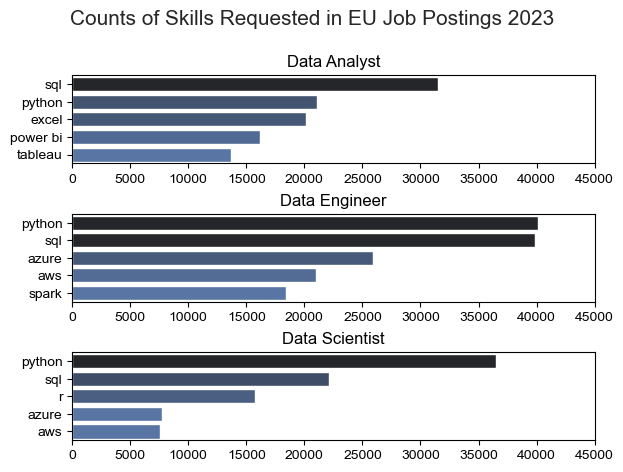

In [7]:
fig, ax = plt.subplots(3,1)

sns.set_theme(style= "ticks")

for i in range(3):
    job_title = job_titles[i]
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title]
    df_plot = df_plot.head(5)
    sns.barplot(
        data = df_plot,
        x = 'skill_count',
        y = 'job_skills',
        hue = 'skill_count',
        palette = 'dark:b_r',
        ax = ax[i],

    )
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 45000)

fig.suptitle('Counts of Skills Requested in EU Job Postings 2023', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()



## Convert Counts to Percentages

#### Focus: Counts don't show what portions of jobs are requesting these skills

So we'll convert the counts into percentages which helps us understand how each job title represents relative to the entire dataset. 

In [8]:
df_job_title_count = df_eu['job_title_short'].value_counts().reset_index(name = 'jobs_total')

df_skills_perc = pd.merge(df_skills_count , df_job_title_count, how = 'left', on = 'job_title_short')

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total
0,python,Data Engineer,40150,72069
1,sql,Data Engineer,39870,72069
2,python,Data Scientist,36510,57175
3,sql,Data Analyst,31498,71057
4,azure,Data Engineer,25883,72069
...,...,...,...,...
2066,wire,Senior Data Scientist,1,11955
2067,airtable,Machine Learning Engineer,1,5761
2068,airtable,Senior Data Engineer,1,15834
2069,wimi,Data Scientist,1,57175


In [9]:
# Count percent
df_skills_perc['skill_perc'] = (df_skills_perc['skill_count']/df_skills_perc['jobs_total']*100).round(2)
df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_perc
0,python,Data Engineer,40150,72069,55.71
1,sql,Data Engineer,39870,72069,55.32
2,python,Data Scientist,36510,57175,63.86
3,sql,Data Analyst,31498,71057,44.33
4,azure,Data Engineer,25883,72069,35.91
...,...,...,...,...,...
2066,wire,Senior Data Scientist,1,11955,0.01
2067,airtable,Machine Learning Engineer,1,5761,0.02
2068,airtable,Senior Data Engineer,1,15834,0.01
2069,wimi,Data Scientist,1,57175,0.00


## Plot Percentage Count

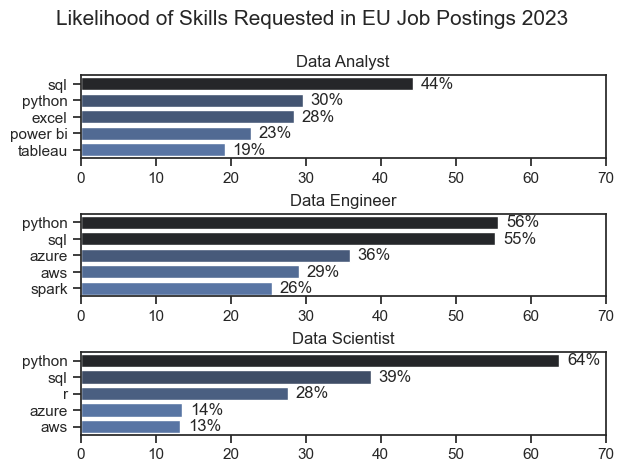

In [11]:
fig, ax = plt.subplots(3,1)

for i in range(3):
    job_title = job_titles[i]
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title]
    df_plot = df_plot.head(5)
    sns.barplot(
        data = df_plot,
        x = 'skill_perc',
        y = 'job_skills',
        hue = 'skill_perc',
        palette = 'dark:b_r',
        ax = ax[i],

    )
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 70)
    for n, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in EU Job Postings 2023', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()